In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def objective_function(x):
    return np.sum(x**2)

In [33]:
def initialize_population(pop_size, dim, lower_bound, upper_bound):
    return np.random.uniform(lower_bound, upper_bound, (pop_size, dim))

In [34]:
def evaluate_population(population):
    return np.array([objective_function(ind) for ind in population])

In [35]:
def clone_population(selected, clone_factor):
    clones = []
    for i, antibody in enumerate(selected):
        num_clones = int(clone_factor / (i + 1))
        clones.extend([antibody.copy() for _ in range(num_clones)])
    return np.array(clones)

In [36]:
def hypermutation(clones, beta, lower_bound, upper_bound):
    mutated = []
    for clone in clones:
        mutation_rate = beta * np.exp(-objective_function(clone))
        new_clone = clone + mutation_rate * np.random.randn(*clone.shape)
        new_clone = np.clip(new_clone, lower_bound, upper_bound)
        mutated.append(new_clone)
    return np.array(mutated)

In [37]:
def replace_population(population, new_cells, pop_size):
    combined = np.vstack((population, new_cells))
    fitness = evaluate_population(combined)
    sorted_indices = np.argsort(fitness)
    return combined[sorted_indices[:pop_size]]

In [38]:
def clonalg(pop_size=50, dim=5, generations=100,
            lower_bound=-5, upper_bound=5,
            selection_size=10, clone_factor=20, beta=1.0):

    population = initialize_population(pop_size, dim, lower_bound, upper_bound)
    best_fitness_history = []

    for gen in range(generations):

        fitness = evaluate_population(population)
        sorted_indices = np.argsort(fitness)
        population = population[sorted_indices]

        selected = population[:selection_size]

        clones = clone_population(selected, clone_factor)

        mutated_clones = hypermutation(
            clones, beta, lower_bound, upper_bound
        )

        population = replace_population(
            population, mutated_clones, pop_size
        )

        best_fitness = objective_function(population[0])
        best_fitness_history.append(best_fitness)

        if gen % 10 == 0:
            print(f"Generation {gen}: Best Fitness = {best_fitness:.6f}")

    return population[0], best_fitness_history

Generation 0: Best Fitness = 5.850629
Generation 10: Best Fitness = 5.544454
Generation 20: Best Fitness = 5.125679
Generation 30: Best Fitness = 4.472996
Generation 40: Best Fitness = 2.769997
Generation 50: Best Fitness = 0.139181
Generation 60: Best Fitness = 0.101552
Generation 70: Best Fitness = 0.072073
Generation 80: Best Fitness = 0.072073
Generation 90: Best Fitness = 0.072073

Best Solution: [ 0.03362601 -0.04827751  0.10632197  0.10814147 -0.21357149]
Best Fitness: 0.07207314819439328


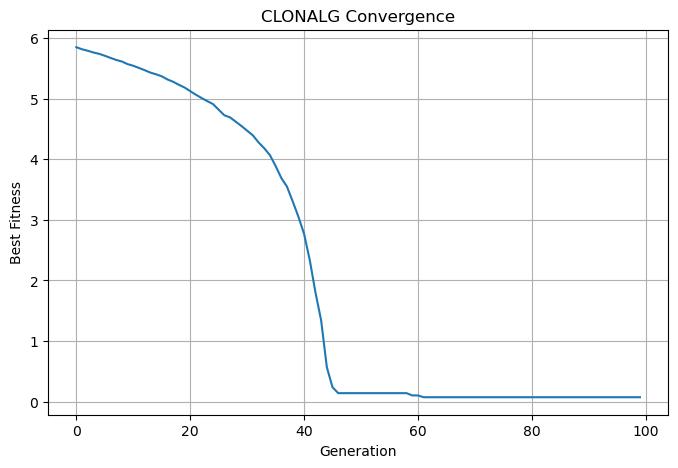

In [39]:
best_solution, history = clonalg()

print("\nBest Solution:", best_solution)
print("Best Fitness:", objective_function(best_solution))

# Plot convergence graph
plt.figure(figsize=(8,5))
plt.plot(history)
plt.title("CLONALG Convergence")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.grid(True)
plt.show()